In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from torch.utils.data import Dataset, DataLoader
from skimage import io, transform
import os
import random

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

class FaceLandmarksDataset(Dataset):
    """Face Landmarks dataset."""

    def __init__(self, csv_file, img_root_dir, transform=None, augment=False):
        self.landmarks_frame = []
        file = open(csv_file, "r")
        while True:
            content=file.readline()
            if not content:
                break
            self.landmarks_frame.append(content.split())
        file.close()
        self.landmarks_frame = self.landmarks_frame[2:]

        self.img_root_dir = img_root_dir
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.landmarks_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        img_name = os.path.join(self.img_root_dir, self.landmarks_frame[idx][0])
        image = io.imread(img_name)
        landmarks = self.landmarks_frame[idx][1:]
        landmarks = np.array([landmarks], dtype=float).reshape(-1, 2)
        # landmarks order: left_eye, right_eye, nose, left_mouth, right_mouth

        # Horizontal flip augmentation
        if self.augment and random.random() > 0.5:
            image = np.fliplr(image).copy()
            img_w = image.shape[1]  # 178
            landmarks[:, 0] = img_w - landmarks[:, 0]
            # Swap: left_eye(0) <-> right_eye(1), left_mouth(3) <-> right_mouth(4)
            landmarks[[0, 1]] = landmarks[[1, 0]]
            landmarks[[3, 4]] = landmarks[[4, 3]]

        scaled_landmarks = landmarks.copy()
        scaled_landmarks[:, 0], scaled_landmarks[:, 1] = scaled_landmarks[:, 0] / 178, scaled_landmarks[:, 1] / 218
        if self.transform:
            image_tr = self.transform(image)
        scaled_landmarks = scaled_landmarks.reshape(-1)
        sample = {'image': image, 'image_tr':image_tr, 'landmarks': landmarks, 'scaled_landmarks': scaled_landmarks}

        return sample


In [3]:
from torchvision import datasets
from torchvision import transforms
full_dataset_root = '/home/tr1bo/Documents/1. School/1. 3B/DeepLearning/lab2,3,4/data/img_align_celeba'
dataset_landmarks = '/home/tr1bo/Documents/1. School/1. 3B/DeepLearning/lab2,3,4/data/landmark/list_landmarks_align_celeba.txt'
full_dataset = FaceLandmarksDataset(dataset_landmarks, full_dataset_root, transform=transform)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_set, test_set = torch.utils.data.random_split(full_dataset, [train_size, test_size])

print(train_set.__len__(), test_set.__len__())

162079 40520


In [6]:
sample = train_set[1000]
landmarks = sample['landmarks']
image = sample['image']
print(sample['image_tr'][0,:5,0:5])
print(sample['scaled_landmarks'].shape)
def show_landmarks(image, landmarks):
    """Show image with landmarks"""
    plt.imshow(image)
    plt.scatter(landmarks[:, 0], landmarks[:, 1], s=5, marker='.', c='r')
    plt.pause(0.001)  # pause a bit so that plots are updated

print(train_set[0])


tensor([[0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000]])
(10,)
{'image': array([[[176, 123,  91],
        [165, 115,  82],
        [156, 107,  77],
        ...,
        [ 62,  39,  23],
        [ 60,  37,  21],
        [ 60,  37,  21]],

       [[172, 119,  87],
        [164, 113,  82],
        [153, 106,  76],
        ...,
        [ 62,  39,  23],
        [ 60,  37,  21],
        [ 60,  37,  21]],

       [[161, 110,  79],
        [156, 107,  75],
        [150, 103,  73],
        ...,
        [ 62,  39,  23],
        [ 60,  37,  21],
        [ 60,  37,  21]],

       ...,

       [[218, 189, 173],
        [224, 195, 179],
        [229, 200, 184],
        ...,
        [ 76,  56,  45],
        [ 64,  46,  34],
        [ 58,  42,  29]],

       [[215, 186, 170],
        [218, 189, 173],
        [2

In [4]:
dataloader = DataLoader(train_set, batch_size=4,
                        shuffle=True, num_workers=0)

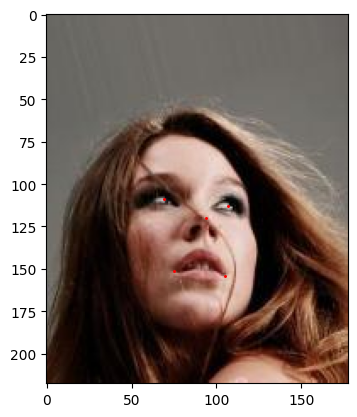

In [7]:
for i in dataloader:
    image = i['image']
    landmarks = i['landmarks']

    img = image[0]          # (218, 178, 3)
    lm = landmarks[0]       # (5, 2)

    plt.figure()
    show_landmarks(img, lm)
    plt.show()

    break